## Safe token management
Use local `.env` file for safe token storage

In [2]:
%load_ext dotenv
%dotenv

In [66]:
import os
from qiskit import transpile
from qiskit.circuit.random import random_circuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.visualization import plot_histogram

In [5]:
token = os.environ["IBMQ_TOKEN"]

In [6]:
service = QiskitRuntimeService(
                token=token,
                channel="ibm_quantum",
            )
backend = service.least_busy(operational=True, simulator=False)

In [50]:
qx = random_circuit(5, depth=2)
qx.measure_all()

In [51]:
qx.draw()

┌────┐┌──────────────┐    ░ ┌─┐            
   q_0: ┤ Sx ├┤0             ├────░─┤M├────────────
        └─┬──┘│              │    ░ └╥┘┌─┐         
   q_1: ──■───┤              ├─X──░──╫─┤M├─────────
              │  Ryy(3.7272) │ │  ░  ║ └╥┘┌─┐      
   q_2: ──■───┤              ├─X──░──╫──╫─┤M├──────
          │   │              │ │  ░  ║  ║ └╥┘┌─┐   
   q_3: ──■───┤1             ├─┼──░──╫──╫──╫─┤M├───
          │   └──────────────┘ │  ░  ║  ║  ║ └╥┘┌─┐
   q_4: ──■────────────────────■──░──╫──╫──╫──╫─┤M├
                                  ░  ║  ║  ║  ║ └╥┘
meas: 5/═════════════════════════════╩══╩══╩══╩══╩═
                                     0  1  2  3  4

In [52]:
transpiled = transpile(qx, backend=backend)

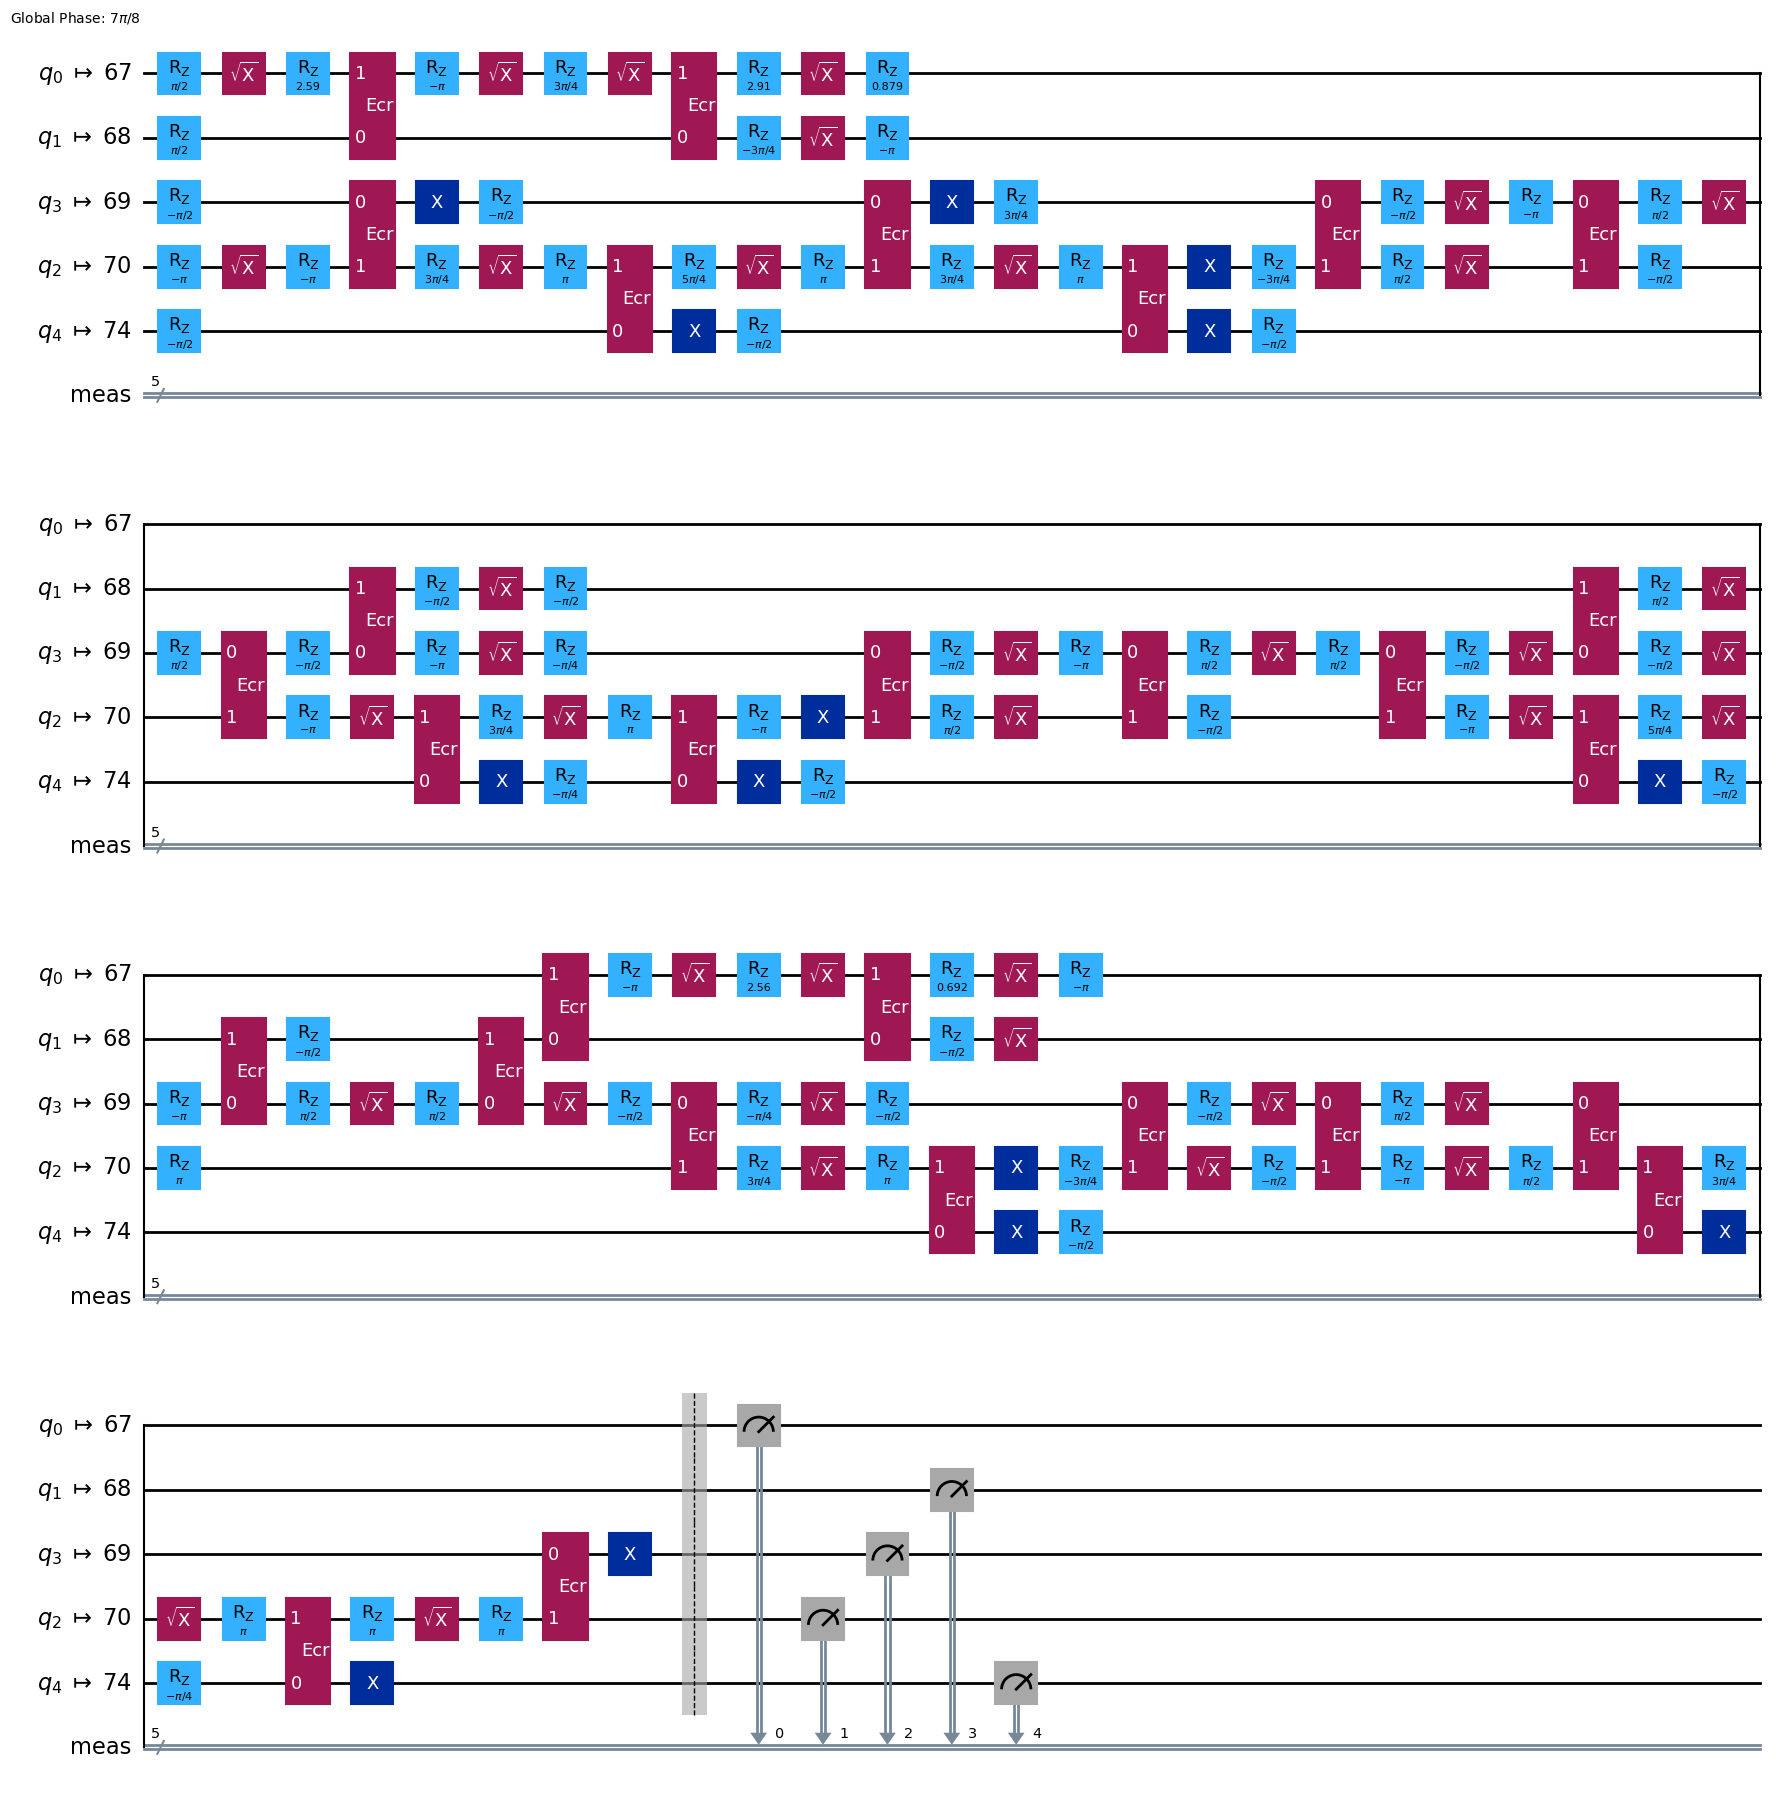

In [53]:
transpiled.draw(output="mpl")

In [54]:
sampler = SamplerV2(backend)
job = sampler.run([transpiled])
result = job.result()

In [55]:
result = job.result()

In [56]:
backend.status()

In [57]:
status.operational

True

In [58]:
status.pending_jobs

4

In [59]:
print(result)

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=4096, num_bits=5>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-04-01 16:45:44', stop='2025-04-01 16:45:46', size=4096>)])}, 'version': 2})


In [60]:
job.status()

'DONE'

In [65]:
pub_result = result[0].data.meas.get_counts()

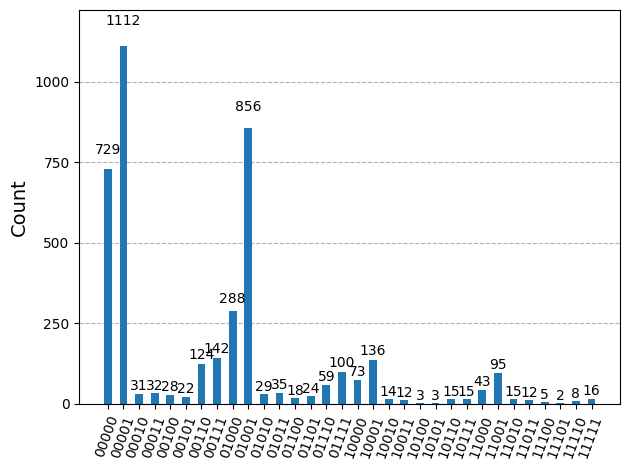

In [67]:
plot_histogram(pub_result)